# Firm characteristics: changing the objective without changing the target

[`05_linear`](05_linear.ipynb) ended on a diagnosis rather than a result. Fitting the whole
cross-section of firm characteristics at once produced nothing on `fwd_ret_1m`, and the
explanation it offered was not about the features - `04_evaluation` had already shown those
order the cross-section one at a time - but about the target. A monthly cross-section of
individual US stocks is extremely heavy-tailed: most firms move a few percent and a few of them
multiply. A linear model fits by **minimizing squared error**, so a firm that returned several
multiples of its price contributes in proportion to the square of that return, while the
**information coefficient** is a rank correlation that counts it as one observation among
thousands. The fit is steered by exactly the observations the metric is indifferent to.

That notebook tested the diagnosis by changing the target - refitting the same grid on the
winsorized variant `fwd_ret_1m_win`. This one tests it a second way, and the second way is
cleaner: **the target is held fixed and the objective is varied instead.** The declared grid
fits every capacity setting under three loss functions on the identical label, identical
features and identical folds:

- **`mse`** minimizes squared error, and is what the linear models minimized.
- **`mae`** minimizes absolute error, so an observation contributes in proportion to how wrong
  it is rather than to its square.
- **`huber`** behaves like squared error for small residuals and like absolute error past a
  threshold derived from each fold's own label spread, so it is quadratic where the data is
  well behaved and linear where it is not.

If the diagnosis in `05_linear` is right, the three objectives should separate on this label,
in that order, and by more than they would on a case study whose returns are better behaved.
Nothing about the features or the sample changes between them.

Two other dials are in the grid, and they are not the point but they are not free either:

- **Capacity**, set by `num_leaves`: how many regions one tree may carve the feature space into.
  Trees also bring what the linear models could not represent at all - an interaction is
  something a tree discovers by splitting on one characteristic inside a region defined by
  others, rather than something someone had to multiply together and name.
- **When to stop**, set by the number of trees. A boosted model has a meaningful state at every
  iteration, so each configuration is scored at ten points along its own training run.

That last one changes how the results must be read. **A checkpoint is part of a configuration,
not a detail of how it was fitted.** Each of the two regression targets declares 15
configurations, which is 150 candidate models apiece; `fwd_class_1m` declares 5, which is 50.
Treating a target's 150 as 15 while quietly keeping each one's best iteration would be
reporting the maximum of ten numbers as though it were one.

**Learning objectives.** By the end of this notebook you will be able to:

- Say why a squared-error fit and a rank correlation can disagree about the same model, and
  design a comparison that isolates the objective from the target.
- Explain why a boosted model produces one result per checkpoint while a linear model produces
  one result in total, and what that implies for counting candidates.
- Read a learning curve of out-of-sample information coefficient against tree count, and tell
  apart a model still learning from one that has begun fitting the training window.
- Recognise that picking each configuration's best checkpoint after seeing the results is a
  selection decision, and locate where selection is actually made.

**Book reference**: Chapter 12, Section 12.2 (GBM libraries) and Section 12.3 (how to tune a
boosted model). Chapter 6, Section 6.7 (Search accounting and run logging) introduces the run
log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) has written the
characteristic matrix, [`04_evaluation`](04_evaluation.ipynb) has screened the characteristics
individually and established the walk-forward folds, and [`05_linear`](05_linear.ipynb) fitted
the linear population this one is compared against.

**What it writes**: one training run per configuration and one complete validation prediction
set per configuration and checkpoint, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`11_backtest`](11_backtest.ipynb) reads that population and selects on validation backtest
Sharpe. **Selection happens there, not here.**

In [1]:
"""Fit the declared firm-characteristics gradient boosting population on the walk-forward folds."""

import plotly.graph_objects as go
import polars as pl
from IPython.display import display
from plotly.subplots import make_subplots

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    narrows_declared_catalog,
    open_study,
    primary_label,
    resolved_model_plan,
    run_model_population,
    supersedes_for_run,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = ""

In [3]:
study = open_study(
    "us_firm_characteristics", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None
)

## 1. Which label, and which models

The label is the one the linear notebook used: `fwd_ret_1m`, the total return over the month
after the decision date, unwinsorized. Holding it fixed is the whole design of this notebook -
the objectives differ, the target does not. The case study also declares `fwd_ret_1m_win`, the
winsorized variant `05_linear` used to make the same point by changing the target instead, and
`fwd_class_1m`, which turns the return into a class. This run fits all three, each against its
own training menu at `config/training/{label}.yaml`.

In [4]:
declared_labels(study, "gbm")

('fwd_class_1m', 'fwd_ret_1m', 'fwd_ret_1m_win')

Each regression target's menu lists 15 named configurations under `gbm:`, and each resolves to
a preset in `case_studies/config/lgb/`. That grid is a product of two axes: five capacity
profiles - `default` uses the library's own leaf count and the rest fix it at 7, 15, 31 and
63 - crossed with the three objectives described above. Every configuration runs the same
number of boosting iterations at the same learning rate, so the grid isolates capacity and
loss rather than confounding them with training length. `fwd_class_1m` declares the same five
capacity profiles against a binary objective, because none of the three regression losses
applies to a class label; its menu is smaller by construction, not by omission.

In [5]:
configs = load_model_configs(
    study,
    "gbm",
    labels=LABELS or None,
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""gbm""","""fwd_class_1m""","""default_binary""","""""","""objective=binary, seed=42"""
"""gbm""","""fwd_class_1m""","""leaves_7_binary""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_class_1m""","""leaves_15_binary""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_class_1m""","""leaves_31_binary""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_class_1m""","""leaves_63_binary""","""""","""bagging_fraction=0.8, bagging_…"
…,…,…,…,…
"""gbm""","""fwd_ret_1m_win""","""leaves_31_mae""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_1m_win""","""leaves_31_huber""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_1m_win""","""leaves_63_mse""","""""","""bagging_fraction=0.8, bagging_…"


`LABELS` and `CONFIG_NAMES` both narrow what is fitted, and a narrowed run declares a different
set of members than the canonical population does. A population is immutable once written, so
such a run must publish under its own name: on a fresh workspace it would otherwise register an
incomplete snapshot under the canonical one, and where the full population already exists the
registry refuses it. The comparison is over `(label, config_name)` pairs rather than row counts,
because a subset can match the canonical population on height while declaring different members,
and it says so here rather than several cells later in a message about hashes.

In [6]:
if narrows_declared_catalog(study, "gbm", configs) and not POPULATION_NAME:
    raise ValueError(
        f"this run fits {configs.height} of the declared label-configuration pairs, so it cannot "
        "publish the canonical population; pass POPULATION_NAME to give it its own"
    )

## 2. Binding the declarations to the data

Resolving reads the label and feature files, computes the fold boundaries, works out the exact
rows each fit must predict, and turns any data-dependent parameter into the number it will use.
Huber's threshold is one of those, and on this label it is the interesting one: it is a fraction
of the training labels' standard deviation, so it is a different number on every fold and is
resolved from that fold's own data rather than fixed in advance.

Nothing is fitted here, so the plan can be inspected first. Four things to check:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row.** A row
  that differs is a configuration measured on a different sample from its neighbours.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out tail visible.
- **`checkpoints` is where this differs from the linear plan.** It is the number of training
  states each configuration will publish predictions for. Multiply it by the number of rows to
  get the number of candidate models this notebook is about to create.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
    notebook="06_gbm",
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,i64,i64,i64,i64,i64,date,date
"""default_binary""",57,3708,252008,10,10,2006-11-30,2015-12-31
"""leaves_15_binary""",57,3708,252008,10,10,2006-11-30,2015-12-31
"""leaves_31_binary""",57,3708,252008,10,10,2006-11-30,2015-12-31
"""leaves_63_binary""",57,3708,252008,10,10,2006-11-30,2015-12-31
"""leaves_7_binary""",57,3708,252008,10,10,2006-11-30,2015-12-31
…,…,…,…,…,…,…,…
"""leaves_63_mae""",57,3708,252008,10,10,2006-11-30,2015-12-31
"""leaves_63_mse""",57,3708,252008,10,10,2006-11-30,2015-12-31
"""leaves_7_huber""",57,3708,252008,10,10,2006-11-30,2015-12-31


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. casts the design matrix to the precision LightGBM works in and leaves missing values in
   place - a tree routes a missing value down its own branch, so imputing a median here would
   hand the model an observation nobody made, which matters on characteristics that are simply
   not reported for some firms in some months,
3. fits the declared number of boosting iterations,
4. predicts the fold's validation rows at each checkpoint, using only the trees built up to that
   iteration.

Step 4 is what makes one fit produce many results. The fold predictions are concatenated into
one series per checkpoint covering the whole validation period, and each becomes its own
registered prediction set with its own identity.

**This notebook resolves its requests before running them, and that decides how the fitting is
ordered.** There are two paths through `run_model_population` and they are not interchangeable.
Handing it unresolved requests, or the plan built from them, reaches the family's batch runner,
which walks folds on the outside and configurations on the inside so that one prepared fold is
live at a time. Handing it resolved requests - what the cell above produces, and what the plan
table two cells up is built from - fits one configuration at a time, each preparing the folds it
needs.

The trade is visible in what you have already read. Resolving first is what let the plan show
`eligible_entities` and the real fold boundaries rather than the identities alone, because those
numbers exist only once the data has been read; the cost is that each configuration prepares its
own folds instead of sharing one prepared set. On this panel that is affordable and the plan is
worth seeing. On a panel where it is not, the notebook passes the plan and gives up the entity
count - [`07_tabular_dl`](07_tabular_dl.ipynb) is the case where that choice goes the other way,
and it says so there.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is what makes the downstream comparison well defined.

In [8]:
population_name = POPULATION_NAME or "us_firm_characteristics-gbm-validation-v1"
# The declared hash is only meaningful where a generation of this name already exists. A preview
# run, a reader's first canonical run against an empty `run_log/`, and a run under a caller-chosen
# `POPULATION_NAME` are all refused by `OfficialPopulation.create` if it is passed anyway. The
# resolution lives in shared code so no notebook branches on the tier.
supersedes = supersedes_for_run(
    study,
    population_name=population_name,
    declared=SUPERSEDES_POPULATION,
    execution_tier=EXECUTION_TIER,
)
execution, population = run_model_population(
    study, resolved, population_name=population_name, supersedes=supersedes
)

# The runner's paths do not all record the same diagnostics, so the split below is printed only
# when every run recorded it. A run fitted or resolved fold by fold carries `fitted_folds` and
# `reused_folds`; one served whole from the registry, and one taken through the single-request
# path, carry neither - they prepared no folds, so they have none to count. Indexing the keys
# raises `KeyError` on those, and defaulting them to zero is worse: it reports every fold as
# served from the registry, which is the opposite of what nothing-recorded means, and it does so
# in a number a reader cannot tell from a measurement.
with_folds = [item for item in execution.diagnostics if "fitted_folds" in item]
print(f"{len(execution.runs)} configurations, fitted or served from the registry")
if with_folds and len(with_folds) == len(execution.diagnostics):
    fitted = sum(len(item["fitted_folds"]) for item in with_folds)
    served = sum(len(item["reused_folds"]) for item in with_folds)
    print(f"folds fitted: {fitted}, folds served from the registry: {served}")
else:
    print(
        f"{len(with_folds)} of {len(execution.diagnostics)} runs recorded fold counts, "
        "so the fitted-against-served split is not reported"
    )
print(f"population {population.name}: {len(population.members)} prediction sets")

35 configurations, fitted or served from the registry
folds fitted: 0, folds served from the registry: 350
population us_firm_characteristics-gbm-validation-v1: 350 prediction sets


On a second run every configuration is served from the registry. Each identity is re-derived
from the inputs, the registry already holds the matching rows, and the runner returns the
stored result rather than fitting again - so re-running this notebook unchanged costs the time
it takes to read the data rather than the time it took to fit.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("us_firm_characteristics", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "gbm", labels=["fwd_ret_1m"], config_names=["leaves_15_huber", "leaves_31_huber"]
)
requests = model_requests(study, configs)
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-gbm-v1")
```

`CONFIG_NAMES` fits a subset of what the menu declares. To fit something new, add a preset at
`case_studies/config/lgb/leaves_127_huber.yaml` and list `leaves_127_huber` under `gbm:` in the
label's menu. Editing an existing preset changes that configuration's identity, so its result
registers as a new row beside the old one rather than replacing it.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per configuration, label and checkpoint. `ic_mean` is the **information coefficient**: in
each validation month, rank the firms by the model's prediction, rank them by the return they
went on to earn, correlate the two rankings, and average that monthly correlation over the
validation period.

**Every count and every aggregate below is keyed on `(label, config_name)`, not on the
configuration name alone.** A name is unique within one label's menu and not across them:
`leaves_15_mae` is declared by both regression targets here. Grouping on the name would average
a configuration's result across the targets it appears in, and concatenate their learning curves
into one line that runs from the last checkpoint of one target back to the first of the next.

Coverage is judged against each label's own maximum number of scorable validation months, so a
label with fewer of them is not marked incomplete for a reason unrelated to any model.

In [9]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "task",
    "complete",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "auc_mean_daily",
    "direction_label",
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort(["label", "ic_mean"], descending=[False, True])

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("gbm execution returned a partial prediction set")

catalog = catalog.with_columns(
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max().over("label")
)

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
# The primary label leads when it was fitted. A subset run that leaves it out orders the panels by
# whichever label it did fit rather than by one that is not there.
panel_labels = [label for label in [primary] if label in present] + [
    label for label in present if label != primary
]
order_label = panel_labels[0]
pairs = catalog.select("label", "config_name").unique().height
print(f"{catalog.height} candidate models: {pairs} label-configuration pairs")
print(f"at {catalog.n_unique('checkpoint_value')} checkpoints each, on {len(panel_labels)} labels")
catalog.select(
    "label",
    "config_name",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
).head(15)

350 candidate models: 35 label-configuration pairs
at 10 checkpoints each, on 3 labels


label,config_name,checkpoint_value,ic_mean,ic_std,ic_n_days,full_coverage
str,str,i64,f64,f64,f64,bool
"""fwd_class_1m""","""leaves_31_binary""",100,0.08404,0.034346,110.0,true
"""fwd_class_1m""","""leaves_15_binary""",250,0.08361,0.033199,110.0,true
"""fwd_class_1m""","""leaves_15_binary""",100,0.083583,0.03626,110.0,true
"""fwd_class_1m""","""leaves_31_binary""",50,0.083572,0.036459,110.0,true
"""fwd_class_1m""","""leaves_15_binary""",200,0.083441,0.033913,110.0,true
…,…,…,…,…,…,…
"""fwd_class_1m""","""leaves_15_binary""",350,0.083067,0.032642,110.0,true
"""fwd_class_1m""","""leaves_31_binary""",200,0.082818,0.032145,110.0,true
"""fwd_class_1m""","""leaves_7_binary""",300,0.082817,0.033948,110.0,true


### The same grid, on each target

The features are the same and the folds are the same throughout, and the two regression targets
share one menu of fifteen configurations, so between those two rows the only thing that
changes is what is being predicted. `fwd_class_1m` declares its own five, because a
squared-error objective has nothing to say about a binary outcome; read that row against the
other two rather than as a third member of one sweep, and read `configurations` to see which
is which.

`ic_mean` is defined for all three, which is what puts them on one axis. `auc_monthly` can be
too, and `auc_scored_against` says what it was scored against: `fwd_class_1m` scores its own
label and leaves that column null, while `fwd_ret_1m` has no classes of its own and is scored
as a ranking signal against `fwd_class_1m`, the declared direction sibling of the same forward
month. Those two rows are therefore comparable on that one number. `fwd_ret_1m_win` declares
no sibling and carries no AUC; null there means not computed, not zero.

In [10]:
by_label = (
    catalog.filter("full_coverage")
    .group_by("label")
    .agg(
        task=pl.col("task").first(),
        configurations=pl.col("config_name").n_unique(),
        candidates=pl.len(),
        scored_months=pl.col("ic_n_days").max(),
        best_ic=pl.col("ic_mean").max(),
        worst_ic=pl.col("ic_mean").min(),
        best_auc_monthly=pl.col("auc_mean_daily").max(),
        auc_scored_against=pl.col("direction_label").drop_nulls().first(),
    )
    .sort("best_ic", descending=True)
)
by_label

label,task,configurations,candidates,scored_months,best_ic,worst_ic,best_auc_monthly,auc_scored_against
str,str,u32,u32,f64,f64,f64,f64,str
"""fwd_class_1m""","""classification""",5,50,110.0,0.08404,0.070137,0.54293,null
"""fwd_ret_1m""","""regression""",15,150,110.0,0.08359,0.006856,0.542486,"""fwd_class_1m"""
"""fwd_ret_1m_win""","""regression""",15,150,110.0,0.083489,0.036303,null,null


### What more trees do

Each line traces one configuration's out-of-sample IC as trees are added to it, inside its own
target's panel. This is the figure the checkpoint dimension exists to produce, and it separates
two things a single end-of-training number cannot.

A line that rises and then flattens has learned what it is going to learn; a line still climbing
at the last checkpoint has not converged at the declared training length, and its final number
is a lower bound rather than a level. The colour is the loss function, which is the axis with a
mechanism behind it.

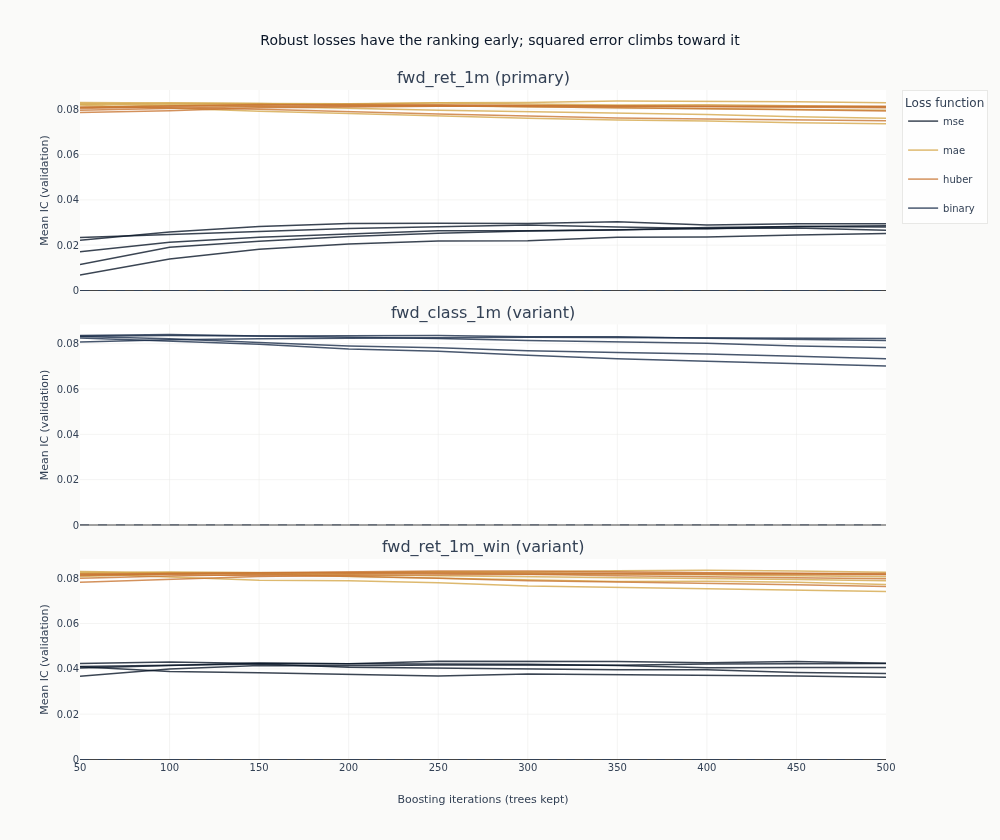

In [11]:
curves = catalog.filter("full_coverage").sort("label", "config_name", "checkpoint_value")
objectives = {
    "mse": COLORS["blue"],
    "mae": COLORS["amber"],
    "huber": COLORS["copper"],
    "binary": COLORS["slate"],
}


def objective_of(name: str) -> str:
    """Read the loss function out of a declared configuration name.

    Raising on an unrecognised name rather than defaulting is the point. The classification
    target declares `*_binary` configurations, and a default of `mse` would draw them in the
    squared-error colour under a legend saying the colour is the loss function.
    """
    match = next((key for key in objectives if name.endswith(key)), None)
    if match is None:
        raise ValueError(f"{name!r} does not end in a declared objective: {sorted(objectives)}")
    return match


# `shared_yaxes` matches axes across columns, so with one column it does nothing and each
# panel would be rescaled to fill itself. Matching every row to the first is what puts the
# targets on one vertical scale, which is what stacking them is for.
fig_curves = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
drawn_objectives: set[str] = set()
for row, label in enumerate(panel_labels, start=1):
    panel = curves.filter(pl.col("label") == label)
    for objective, color in objectives.items():
        members = [
            name
            for name in panel.get_column("config_name").unique(maintain_order=True)
            if objective_of(name) == objective
        ]
        for config_name in members:
            series = panel.filter(pl.col("config_name") == config_name)
            fig_curves.add_trace(
                go.Scatter(
                    x=series.get_column("checkpoint_value").to_list(),
                    y=series.get_column("ic_mean").to_list(),
                    mode="lines",
                    name=objective,
                    legendgroup=objective,
                    # One legend entry per loss function, not per configuration: the colour is
                    # the claim, and thirty-five named lines would bury it.
                    showlegend=objective not in drawn_objectives,
                    line=dict(color=color, width=1.5),
                    opacity=0.8,
                ),
                row=row,
                col=1,
            )
            drawn_objectives.add(objective)
    fig_curves.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_curves.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
    if row > 1:
        fig_curves.update_yaxes(matches="y", row=row, col=1)
fig_curves.update_xaxes(title_text="Boosting iterations (trees kept)", row=len(panel_labels), col=1)
fig_curves.update_layout(
    title="Robust losses have the ranking early; squared error climbs toward it",
    height=280 * len(panel_labels),
    width=1000,
    margin=dict(t=90),
    legend=dict(title_text="Loss function"),
)
# How many configurations are still climbing at the last checkpoint is a fact about the frame, so
# the alt text reads it rather than asserting a shape the next run may not reproduce.
climbing = (
    curves.group_by("label", "config_name")
    .agg(
        first_ic=pl.col("ic_mean").sort_by("checkpoint_value").first(),
        last_ic=pl.col("ic_mean").sort_by("checkpoint_value").last(),
        peak_checkpoint=pl.col("checkpoint_value").sort_by("ic_mean", descending=True).first(),
        last_checkpoint=pl.col("checkpoint_value").max(),
    )
    .with_columns(
        gain=pl.col("last_ic") - pl.col("first_ic"),
        peaks_at_the_end=pl.col("peak_checkpoint") == pl.col("last_checkpoint"),
    )
)
climb_text = "; ".join(
    f"{row['label']}: {row['at_end']} of {row['total']}"
    for row in climbing.group_by("label")
    .agg(total=pl.len(), at_end=pl.col("peaks_at_the_end").sum())
    .sort("label")
    .iter_rows(named=True)
)
show_plotly_with_alt(
    fig_curves,
    "Line charts of mean validation information coefficient against boosting iteration, one line "
    "per configuration, coloured by loss function: dark navy for squared error, gold for absolute "
    "error, copper for Huber, slate for the binary objective the classification target declares. "
    "One panel per label on one shared pair of axes, each with a dashed zero line. Counted from "
    "the "
    f"frame, the configurations whose highest point is their last checkpoint are {climb_text}. "
    "The gold and copper lines sit above the navy ones in both regression panels.",
)

### Whether the loss function is what separates them

The chart below drops the checkpoint dimension by taking each configuration's final state, so
every configuration is compared at the same amount of training. That is the comparison that does
not require choosing anything after the fact. The configurations are held in one order across
the panels - their ranking on the primary target - so a panel that does not descend is a target
that orders the grid differently.

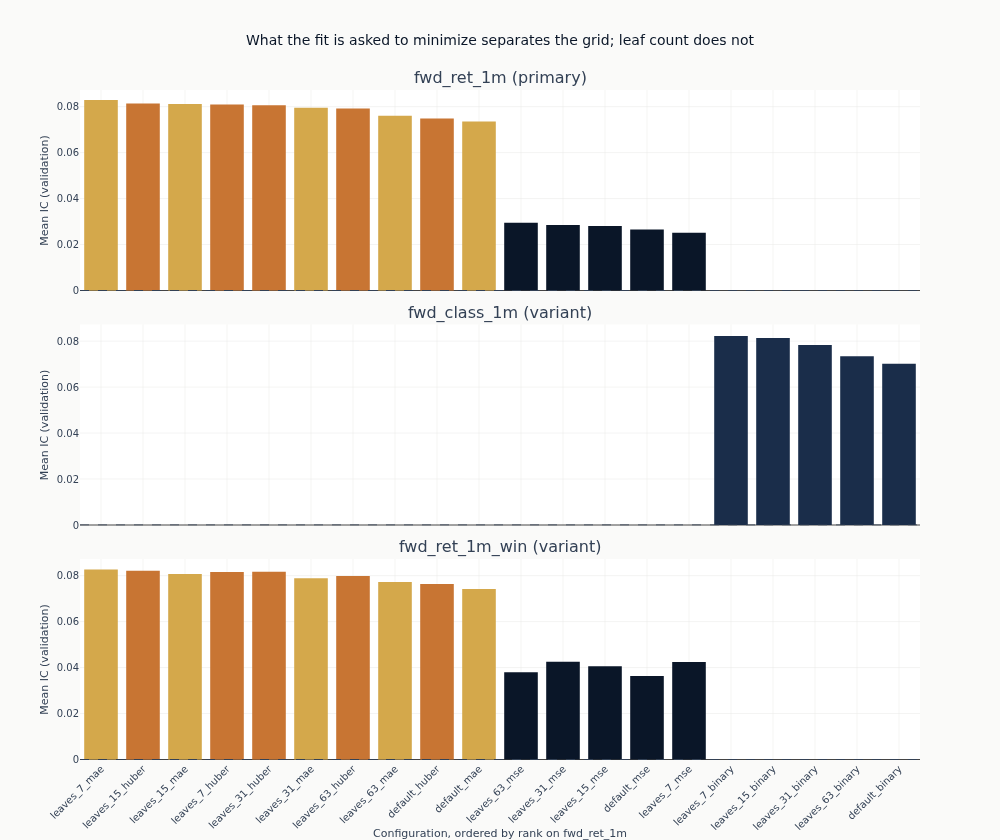

In [12]:
final = (
    catalog.filter(pl.col("checkpoint_value") == pl.col("checkpoint_value").max().over("label"))
    .filter("full_coverage")
    .sort(["label", "ic_mean"], descending=[False, True])
)
final_iteration = int(final.get_column("checkpoint_value").max())
config_order = (
    final.filter(pl.col("label") == order_label)
    .sort("ic_mean", descending=True)
    .get_column("config_name")
    .to_list()
)

# `shared_yaxes` matches axes across columns, so with one column it does nothing and each
# panel would be rescaled to fill itself. Matching every row to the first is what puts the
# targets on one vertical scale, which is what stacking them is for.
fig_obj = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
for row, label in enumerate(panel_labels, start=1):
    panel = final.filter(pl.col("label") == label)
    # The classification target declares its own configurations; they keep them and append them
    # after the shared order rather than being dropped from the figure.
    order = [name for name in config_order if name in set(panel.get_column("config_name"))]
    order += [name for name in panel.get_column("config_name").to_list() if name not in order]
    panel = panel.with_columns(
        rank=pl.col("config_name").replace_strict(
            {name: index for index, name in enumerate(order)}, return_dtype=pl.Int32
        )
    ).sort("rank")
    fig_obj.add_trace(
        go.Bar(
            x=panel.get_column("config_name").to_list(),
            y=panel.get_column("ic_mean").to_list(),
            marker_color=[
                objectives[objective_of(name)] for name in panel.get_column("config_name")
            ],
            showlegend=False,
        ),
        row=row,
        col=1,
    )
    fig_obj.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_obj.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
    if row > 1:
        fig_obj.update_yaxes(matches="y", row=row, col=1)
fig_obj.update_xaxes(
    title_text=f"Configuration, ordered by rank on {order_label}",
    tickangle=-45,
    row=len(panel_labels),
    col=1,
)
fig_obj.update_layout(
    title="What the fit is asked to minimize separates the grid; leaf count does not",
    height=280 * len(panel_labels),
    width=1000,
    margin=dict(t=90),
)
show_plotly_with_alt(
    fig_obj,
    "Bar charts of mean validation information coefficient at the final boosting iteration, one "
    "panel per label on one shared vertical scale, bars coloured by loss function and held in "
    "the "
    "primary target's ranking order in every panel. In both regression panels the gold and copper "
    "bars group together above the navy ones rather than interleaving, and within each colour "
    "group the bars are of similar height across the five leaf counts. Each panel carries a "
    "dashed zero line.",
)

### Which of the two axes moved the result

The two frames below are the claims the charts make, computed rather than read off them, and
they sit together because they are read against each other.

`by_objective` gives, for each target, the range each objective covers and whether the groups
overlap. Complete separation is a stronger statement than a difference in means, and it is the
one the chart appears to show.

`checkpoint_vs_grid` puts the range a configuration's IC covers across its own ten checkpoints
against the spread across that target's whole grid at fixed training length. That is the
quantity that decides whether choosing a stopping point is a decision worth making carefully or
one being made by noise. Both are computed inside a target, because comparing a within-run range
against a spread taken across targets would compare two different things.

In [13]:
by_objective = (
    final.with_columns(
        objective=pl.col("config_name").map_elements(objective_of, return_dtype=pl.Utf8)
    )
    .group_by("label", "objective")
    .agg(
        configurations=pl.len(),
        ic_min=pl.col("ic_mean").min(),
        ic_max=pl.col("ic_mean").max(),
        ic_median=pl.col("ic_mean").median(),
    )
    .sort(["label", "ic_median"], descending=[False, True])
)
spread = (
    curves.group_by("label", "config_name")
    .agg(
        ic_min=pl.col("ic_mean").min(),
        ic_max=pl.col("ic_mean").max(),
        ic_final=pl.col("ic_mean").filter(pl.col("checkpoint_value") == final_iteration).first(),
    )
    .with_columns(checkpoint_range=pl.col("ic_max") - pl.col("ic_min"))
    .sort("checkpoint_range", descending=True)
)
checkpoint_vs_grid = (
    spread.group_by("label")
    .agg(median_checkpoint_range=pl.col("checkpoint_range").median())
    .join(
        final.group_by("label").agg(
            across_configurations=pl.col("ic_mean").max() - pl.col("ic_mean").min()
        ),
        on="label",
    )
    .with_columns(
        checkpoint_dominates=pl.col("median_checkpoint_range") > pl.col("across_configurations")
    )
    .sort("label")
)
print(f"compared at {final_iteration} boosting iterations")
display(by_objective)
checkpoint_vs_grid

compared at 500 boosting iterations


label,objective,configurations,ic_min,ic_max,ic_median
str,str,u32,f64,f64,f64
"""fwd_class_1m""","""binary""",5,0.070137,0.082277,0.078289
"""fwd_ret_1m""","""huber""",5,0.074884,0.081338,0.080612
"""fwd_ret_1m""","""mae""",5,0.073573,0.082863,0.079537
"""fwd_ret_1m""","""mse""",5,0.025168,0.029498,0.028061
"""fwd_ret_1m_win""","""huber""",5,0.076347,0.082095,0.081546
"""fwd_ret_1m_win""","""mae""",5,0.074185,0.082663,0.078901
"""fwd_ret_1m_win""","""mse""",5,0.036303,0.04248,0.040568


label,median_checkpoint_range,across_configurations,checkpoint_dominates
str,f64,f64,bool
"""fwd_class_1m""",0.005751,0.01214,false
"""fwd_ret_1m""",0.00551,0.057696,false
"""fwd_ret_1m_win""",0.003606,0.04636,false


## 5. What to notice

**The objective decides the result, and `by_objective` says whether the separation is complete.**
Read that frame before the ranking: complete separation between the robust losses and squared
error is a much stronger statement than a gap between medians, and it either holds on a target
or it does not. That is the prediction [`05_linear`](05_linear.ipynb) made from the shape of this
label before anything was fitted, and this is its controlled form - the characteristics, the
folds and the months scored are identical across the grid, the outcome the IC is measured
against is the same continuous return in every case, and only what the fit was asked to minimize
differs.

**Fitting both return targets is what makes it a controlled test rather than an anecdote.**
`fwd_ret_1m_win` is `fwd_ret_1m` with each month's cross-section clipped at its own tails, so if
the tails are what penalizes squared error, clipping them should lift the squared-error group
and leave the robust group where it was. That is a directional prediction about two rows of
`by_objective`, and it is available only because one run fitted both.

**What matters is robust or not, rather than which robust loss.** Absolute error and Huber
interleave, and the spread within that group is small next to the distance to squared error.
Huber exists to be quadratic where the data is well behaved and linear where it is not, and on a
target this heavy-tailed almost everything of consequence lies in the region where it has
already become absolute error. So the decision worth making carefully is whether the extremes
are allowed to steer the fit at all.

**The loss function is worth far more than the capacity.** Within either group, moving the leaf
count from 7 to 63 changes the IC by a small fraction of what changing the objective changes.
The dial the literature spends most of its tuning effort on is, on this data, an order of
magnitude less important than the one that is usually left at its default.

**The learning curves say why, and this is the mechanism made visible.** The robust-loss
configurations arrive at their level early and stay flat; the squared-error ones start low and
climb, and the `climbing` frame counts how many are still at their highest point when training
stops. Squared error weights an observation by the square of its error, so its early trees are
spent on the firms that multiplied, which is effort a rank correlation is indifferent to; it
accumulates ranking information slowly and as a by-product. Absolute error weights an
observation by how wrong it is, and gets the ranking immediately. A configuration still climbing
at the last checkpoint has not converged at the declared training length, so its final number is
a lower bound on what that objective would eventually reach.

**How much the checkpoint matters is a property of the data, not a general fact.** Read
`checkpoint_dominates`: where the median within-run range exceeds the spread across the grid,
the leading configuration was chosen by where its training run happened to be. On this case
study the objective gap is large enough to dominate, so the stopping point barely moves the
answer - which is the opposite of what the same grid shows where the objectives do not separate.
Neither is the general case, and that is why the checkpoint is registered as part of a
configuration rather than resolved away.

**None of this selects anything.** IC measures whether predictions rank firms correctly, not
whether a strategy trading them makes money after costs and turnover. A monthly cross-section of
individual stocks is also where the ranking advantage and the tradeable advantage diverge most,
because the firms whose returns are hardest to predict are disproportionately the small and
illiquid ones. Selection is on validation backtest Sharpe over the population just published,
and it happens in [`11_backtest`](11_backtest.ipynb), where the checkpoint is part of what is
selected.

**Known limitations.** The IC is an average of monthly rank correlations with no adjustment for
serial dependence, so it is a diagnostic rather than a test, and it carries no interval that
would say whether absolute error and Huber differ from each other - the reading above is that
they do not, and the evidence for that is the size of the within-group spread rather than a
test. The grid varies capacity and loss at a fixed learning rate and a fixed training length,
and the learning curves are the reason the last of those matters. And every number is measured
on validation folds that have been read many times over by the time a case study reaches this
notebook.

**Next**: [`07_tabular_dl`](07_tabular_dl.ipynb) asks the same question of a neural network built
for tabular data. It optimizes a loss function too, and the one it is given is a choice made the
same way this one was - so the thing to watch is whether the objective matters there for the
same reason it matters here.